<a href="https://colab.research.google.com/github/slr549/Sistem-Klasifikasi-Risiko-Kelayakan-Kredit-Berbasis-AI/blob/main/Tugas_UAS_AI_Raki_Raihan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek: Sistem Klasifikasi Risiko Kelayakan Kredit Berbasis AI

**Tujuan:** Menggabungkan analisis data numerik tradisional dengan sentimen teks (NLP) untuk menentukan kelayakan kredit.

---

**Instalasi Library & Inisialisasi**

## 🛠️ Slide 1: Persiapan Lingkungan & Tracking Eksperimen

Pada tahap ini, kita melakukan:
*   **Instalasi Library:** Menyiapkan `transformers` untuk NLP dan `scikit-learn` untuk Machine Learning.
*   **WandB Initialization:** Mengintegrasikan sistem tracking untuk memantau performa model secara real-time.
*   **Environment Setup:** Memastikan semua package versi terbaru siap digunakan.

In [130]:
# Instalasi Library
!pip install -q transformers wandb scikit_learn pandas numpy joblib

import pandas as pd
import numpy as np
import wandb
import joblib
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, pair_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi WandB
wandb.login()

# Inisialisasi Tracking excperiment UAS
wandb.init(
    project="UAS-AI-Klasifikasi-Risiko",
    name="Excperiment-GradientBoosting",
    config={
        "algoritma": "GradientBoostingClassifier + IndoRoBERTa",
        "test_size": 0.2,
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3
    }
)
print("Setup Lingkungan Selesai!")

wandb: WARNING Unable to verify login in offline mode.


Setup Lingkungan Selesai!


**Dataset Preparation & Exploratory Data Analysis**

## 📊 Slide 2: Eksplorasi & Preprocessing Data

Data adalah fondasi utama. Di sini kita:
*   **Data Simulation:** Membuat data dummy yang mencakup pendapatan, tanggungan, dan catatan kondisi nasabah.
*   **Handling Missing Values:** Mengisi data yang kosong menggunakan *median* dan *mode* agar model tidak bias.
*   **Visualisasi:** Melihat distribusi target (Layak vs Tidak Layak) untuk memastikan data tidak terlalu timpang (imbalanced).

Data Dummy

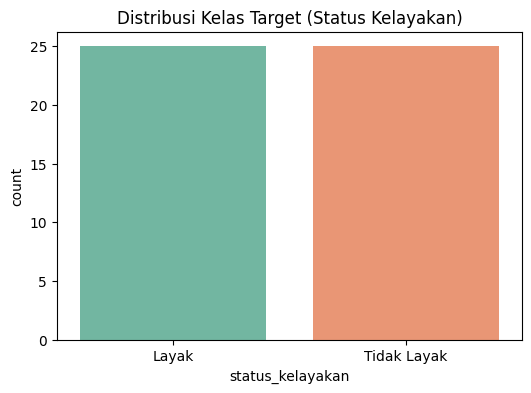


Data Siap Diproses Lebih Lanjut!


,pendapatan_bulanan,jumlah_tanggungan,catatan_kondisi,status_kelayakan
0,8423388.0,5.0,"Krisis keuangan, banyak utang",Layak
1,8550634.0,1.0,Kondisis Keuangan Sangat Stabil,Tidak Layak
2,12081351.0,1.0,Kondisis Keuangan Sangat Stabil,Layak
3,6304572.0,0.0,Kondisis Keuangan Sangat Stabil,Layak
4,4234489.0,1.0,Kondisis Keuangan Sangat Stabil,Layak


In [131]:
# Create Dummy Dataset
np.random.seed(42)
data_size = 50

data = {
    'pendapatan_bulanan': np.random.randint(2000000, 15000000, data_size).astype(float),
    'jumlah_tanggungan': np.random.randint(0, 6, data_size).astype(float),
    'catatan_kondisi': np.random.choice(
        [
            "Kondisis Keuangan Sangat Stabil",
            "Buguh bantuan mendesak karena PHK",
            "Cukup aman untuk saat ini",
            "Sangat aman dan tidak ada masalah",
            "Krisis keuangan, banyak utang"
        ],
        data_size
    ),
    'status_kelayakan': np.random.choice(['Layak', 'Tidak Layak'], data_size)
}

# Sisipkan beberapa missing values untuk simulasi preprocessing
data['pendapatan_bulanan'][5] = np.nan
data['jumlah_tanggungan'][10] = np.nan

df = pd.DataFrame(data)
#df.head()

# Preprocessing: Handling Missing Values
df['pendapatan_bulanan'] = df['pendapatan_bulanan'].fillna(df['pendapatan_bulanan'].median())
df['jumlah_tanggungan'] = df['jumlah_tanggungan'].fillna(df['jumlah_tanggungan'].mode()[0])

# Visualisasi Sederhana
plt.figure(figsize=(6, 4))
sns.countplot(x='status_kelayakan', data=df, palette='Set2', hue='status_kelayakan', legend=False)
plt.title('Distribusi Kelas Target (Status Kelayakan)')
plt.show()

print("\nData Siap Diproses Lebih Lanjut!")
display(df.head())

**Feature Engineering Based On AI (NLP Hugging Face)**

## 🤖 Slide 3: NLP Feature Engineering (IndoBERTa)

Inovasi utama dalam sistem ini:
*   **Sentiment Analysis:** Menggunakan model *IndoBERTa* untuk membaca catatan manual nasabah.
*   **Feature Extraction:** Mengubah teks emosional (seperti 'Saya kena PHK') menjadi skor risiko numerik yang bisa dipahami oleh algoritma ML.

In [132]:
print("Memuat Model NLP IndoBERTa dari Hugging Face...")
nlp_classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier" # Corrected model name
)

def ekstrak_skor_nlp(teks):
  """
  Teks negatif (Krisis/butuh bantuan) -> skor dekat 1 (Risiko/Prioritas Tinggi).
  Teks positif (aman) -> skor dekat 0.
  """
  hasil = nlp_classifier(teks)[0]
  if hasil['label'] == 'negative': # Assuming the label returned is 'negative'
      return hasil['score']
  else:
      return 1 - hasil['score']

# Menerapkan NLP
print("Mengekstraksi fitur teks...")
df['skor_nlp_kondisi'] = df['catatan_kondisi'].apply(ekstrak_skor_nlp)

display(df[['catatan_kondisi', 'skor_nlp_kondisi']].head())

Memuat Model NLP IndoBERTa dari Hugging Face...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Mengekstraksi fitur teks...


,catatan_kondisi,skor_nlp_kondisi
0,"Krisis keuangan, banyak utang",0.955640
1,Kondisis Keuangan Sangat Stabil,0.038816
2,Kondisis Keuangan Sangat Stabil,0.038816
3,Kondisis Keuangan Sangat Stabil,0.038816
4,Kondisis Keuangan Sangat Stabil,0.038816


**Preprocessing & End Training**

## 🏋️ Slide 4: Pelatihan Model & Evaluasi Awal

Proses teknis di balik layar:
*   **Standardization:** Menyamakan skala pendapatan dan jumlah tanggungan.
*   **Base Model:** Melatih *Random Forest* sebagai model benchmark.
*   **Metrics:** Menggunakan *Classification Report* dan *Confusion Matrix* untuk melihat di mana model sering melakukan kesalahan prediksi.

Melatih Model Random Forest...

=== Laporan Klasifikasi (Classification Report) ===
              precision    recall  f1-score   support

       Layak       0.33      0.40      0.36         5
 Tidak Layak       0.25      0.20      0.22         5

    accuracy                           0.30        10
   macro avg       0.29      0.30      0.29        10
weighted avg       0.29      0.30      0.29        10



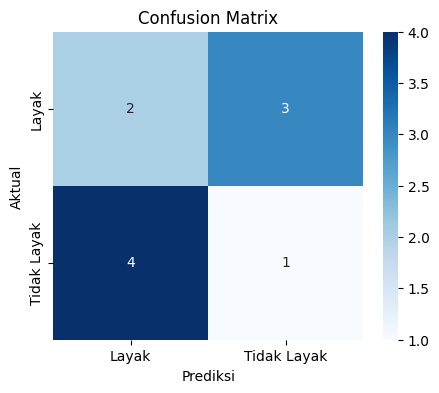

In [133]:
# Scaling Fitur Numerik
scaler = StandardScaler()
df[['pendapatan_bulanan', 'jumlah_tanggungan']] = scaler.fit_transform(df[['pendapatan_bulanan', 'jumlah_tanggungan']])

# Encoding Target
encoder = LabelEncoder()
df['status_kelayakan'] = encoder.fit_transform(df['status_kelayakan'])

# Split Data
X = df[['pendapatan_bulanan', 'jumlah_tanggungan', 'skor_nlp_kondisi']]
y = df['status_kelayakan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Model Random Forest
print("Melatih Model Random Forest...\n")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluasi Mendalam
y_pred = rf_model.predict(X_test)

print("=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Inverse transform y_test and y_pred to original labels for wandb.plot.confusion_matrix
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

# Log ke W&B dan Akhiri Tracking
#wandb.log({
#    "accuracy": accuracy_score(y_test, y_pred),
#    "confusion_matrix": wandb.plot.confusion_matrix(probs=None, y_true=y_test_labels, preds=y_pred_labels, class_names=list(encoder.classes_)) # Convert to list
#})
#wandb.finish()

**Merge Model NLP, GridSearchCV & Joblip**

## 🚀 Slide 5: Optimasi Model & Deployment

Langkah terakhir untuk mencapai performa terbaik:
*   **Hyperparameter Tuning:** Mencari kombinasi parameter terbaik untuk *Gradient Boosting*.
*   **Persistence:** Menyimpan model (`.joblib`) agar bisa langsung digunakan di aplikasi produksi.
*   **Real-world Simulation:** Menguji model dengan input data baru untuk melihat bagaimana AI memberikan keputusan secara instan.

In [134]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import joblib
import numpy as np
import wandb

print("=== Tahap 1: Hyperparameter Tuning Gradient Boosting ===")

# 1. Definisikan Ruang Pencarian (Hyperparameter Space)
param_grid = {
    'n_estimators': [50, 100, 150],      # Jumlah pohon
    'learning_rate': [0.01, 0.1, 0.2],   # Tingkat pembelajaran
    'max_depth': [3, 5, 7]               # Kedalaman maksimal pohon
}

# 2. Inisialisasi GridSearchCV
print("Memulai pencarian hyperparameter terbaik untuk GradientBoostingClassifier... (Mohon tunggu)")
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,           # 5-Fold Cross Validation
    n_jobs=-1,      # Menggunakan seluruh core CPU yang tersedia di Colab
    scoring='accuracy'
)

# 3. Eksekusi Pencarian
# (Pastikan X_train, y_train, X_test, y_test, dan encoder sudah didefinisikan sebelumnya)
grid_search.fit(X_train, y_train)

# 4. Ambil Model Terbaik
gbc_model_best = grid_search.best_estimator_

print("\n=== Hasil Hyperparameter Tuning (GradientBoostingClassifier) ===")
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"Akurasi Validasi Silang   : {grid_search.best_score_ * 100:.2f}%")


# 5. Evaluasi pada Data Uji & Log ke W&B
y_pred_gbc = gbc_model_best.predict(X_test)
akurasi_test = accuracy_score(y_test, y_pred_gbc)

# Log ke W&B (Uncommented and fixed)
if wandb.run is None:
    print("WandB run not active. Re-initializing wandb for GradientBoosting experiment...")
    wandb.init(
        project="UAS-AI-Klasifikasi-Risiko",
        name="Excperiment-GradientBoosting",
        config={
            "algoritma": "GradientBoostingClassifier + IndoRoBERTa",
            "test_size": 0.2,
            "n_estimators": grid_search.best_params_['n_estimators'],
            "learning_rate": grid_search.best_params_['learning_rate'],
            "max_depth": grid_search.best_params_['max_depth']
        }
    )
wandb.log({
    "best_cv_accuracy": grid_search.best_score_,
    "test_accuracy": akurasi_test,
    "best_learning_rate": grid_search.best_params_['learning_rate'],
    "best_max_depth": grid_search.best_params_['max_depth'],
    "confusion_matrix": wandb.plot.confusion_matrix(probs=None, y_true=y_test.values, preds=y_pred_gbc, class_names=encoder.classes_)
})

# Selesaikan sesi tracking W&B untuk eksperimen ini
if wandb.run is not None:
    wandb.finish()


print("\n=== Tahap 2: Ekspor Model & Scaler ===")
# Pastikan yang disimpan adalah model hasil tuning (gbc_model_best)
joblib.dump(gbc_model_best, 'model_gbc_uas.joblib')
joblib.dump(scaler, 'scaler_uas.joblib')
print("Artefak model (model_gbc_uas.joblib) dan scaler berhasil disimpan di storage Colab!")


print("\n=== Tahap 3: Simulasi Prediksi Kasus Baru ===")
def prediksi_kandidat_baru(pendapatan, tanggungan, catatan_teks):
    # Load ulang artefak (Simulasi environment production)
    loaded_model = joblib.load('model_gbc_uas.joblib')
    loaded_scaler = joblib.load('scaler_uas.joblib')

    # Ekstrak NLP (Fungsi ekstrak_skor_nlp harus sudah dijalankan di sel sebelumnya)
    skor_teks = ekstrak_skor_nlp(catatan_teks)

    # Scaling numerik (Pastikan input berbentuk DataFrame dengan nama kolom yang benar)
    numerik_df = pd.DataFrame([[pendapatan, tanggungan]], columns=['pendapatan_bulanan', 'jumlah_tanggungan'])
    numerik_scaled = loaded_scaler.transform(numerik_df)

    # Gabungkan fitur ke dalam DataFrame (sesuai urutan saat training)
    fitur_final_df = pd.DataFrame([[numerik_scaled[0][0], numerik_scaled[0][1], skor_teks]],
                                  columns=['pendapatan_bulanan', 'jumlah_tanggungan', 'skor_nlp_kondisi'])

    # Prediksi menggunakan model yang sudah di-load
    hasil_prediksi = loaded_model.predict(fitur_final_df)[0]
    probabilitas = loaded_model.predict_proba(fitur_final_df)[0]

    # Kembalikan label asli
    label_hasil = encoder.inverse_transform([hasil_prediksi])[0]

    # Ambil probabilitas kelas yang diprediksi (Tingkat Keyakinan)
    confidence = probabilitas[hasil_prediksi] * 100

    print(f"\n[KASUS BARU]")
    print(f"Pendapatan  : Rp {pendapatan:,}")
    print(f"Tanggungan  : {tanggungan} orang")
    print(f"Catatan     : '{catatan_teks}'")
    print(f"Skor NLP    : {skor_teks:.4f}")
    print(f"-> Keputusan: {label_hasil} (Keyakinan ML: {confidence:.2f}%)")

# Uji Coba dengan Data Baru
prediksi_kandidat_baru(3000000, 4, "Saya baru saja kena PHK dan butuh biaya sekolah anak")
prediksi_kandidat_baru(50000000000, 11, "Saya Krisis keuangan")
prediksi_kandidat_baru(15000000, 1, "Keuangan stabil dan tabungan cukup")

=== Tahap 1: Hyperparameter Tuning Gradient Boosting ===
Memulai pencarian hyperparameter terbaik untuk GradientBoostingClassifier... (Mohon tunggu)

=== Hasil Hyperparameter Tuning (GradientBoostingClassifier) ===
Kombinasi Parameter Terbaik : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Akurasi Validasi Silang   : 55.00%


best_cv_accuracy,▁
best_learning_rate,▁
best_max_depth,▁
test_accuracy,▁
best_cv_accuracy,0.55
best_learning_rate,0.01
best_max_depth,3
test_accuracy,0.3



=== Tahap 2: Ekspor Model & Scaler ===
Artefak model (model_gbc_uas.joblib) dan scaler berhasil disimpan di storage Colab!

=== Tahap 3: Simulasi Prediksi Kasus Baru ===

[KASUS BARU]
Pendapatan  : Rp 3,000,000
Tanggungan  : 4 orang
Catatan     : 'Saya baru saja kena PHK dan butuh biaya sekolah anak'
Skor NLP    : 0.0830
-> Keputusan: Tidak Layak (Keyakinan ML: 50.48%)

[KASUS BARU]
Pendapatan  : Rp 50,000,000,000
Tanggungan  : 11 orang
Catatan     : 'Saya Krisis keuangan'
Skor NLP    : 0.8026
-> Keputusan: Tidak Layak (Keyakinan ML: 69.28%)

[KASUS BARU]
Pendapatan  : Rp 15,000,000
Tanggungan  : 1 orang
Catatan     : 'Keuangan stabil dan tabungan cukup'
Skor NLP    : 0.0479
-> Keputusan: Tidak Layak (Keyakinan ML: 69.28%)


### 💡 Bagaimana Cara Kerja Gradient Boosting? (Analogi Sederhana)

Bayangkan Anda sedang belajar memanah:

1.  **Percobaan Pertama:** Anda melepaskan anak panah pertama. Hasilnya meleset 10 cm ke kanan dari pusat sasaran.
2.  **Koreksi:** Alih-alih membuang hasil pertama, Anda fokus pada kesalahan tersebut (meleset 10 cm ke kanan). Anda mencoba lagi dengan mengoreksi bidikan sedikit ke kiri.
3.  **Percobaan Kedua:** Sekarang Anda hanya meleset 2 cm. Anda belajar lagi dari sisa kesalahan yang kecil itu.
4.  **Iterasi:** Proses ini berulang berkali-kali. Setiap 'pohon' baru dalam model bertugas memperbaiki kesalahan yang dibuat oleh pohon sebelumnya.

**Kesimpulan:** Gradient Boosting adalah tim 'ahli' di mana setiap anggota belajar khusus dari kesalahan anggota sebelumnya, sehingga hasil akhirnya menjadi sangat akurat.

## 🔍 Slide 6: Analisis Fitur Paling Berpengaruh (Feature Importance)

Tidak semua data memiliki bobot yang sama. Di bagian ini, kita membedah model untuk melihat faktor apa yang paling menentukan apakah seseorang layak mendapatkan kredit atau tidak menurut AI kita.

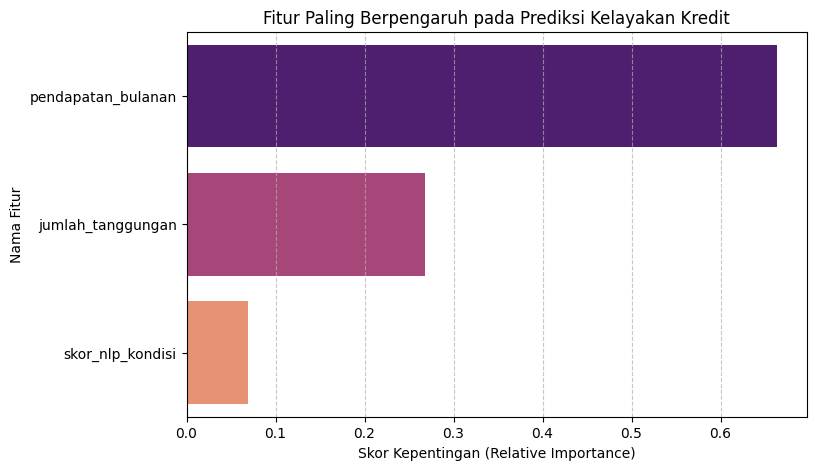

Ringkasan Kontribusi Fitur:
- pendapatan_bulanan: 66.34%
- jumlah_tanggungan: 26.75%
- skor_nlp_kondisi: 6.91%


In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mendapatkan feature importance dari model terbaik
importances = gbc_model_best.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importances}).sort_values(by='Kepentingan', ascending=False)

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x='Kepentingan', y='Fitur', data=feature_importance_df, palette='magma', hue='Fitur', legend=False)
plt.title('Fitur Paling Berpengaruh pada Prediksi Kelayakan Kredit')
plt.xlabel('Skor Kepentingan (Relative Importance)')
plt.ylabel('Nama Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Ringkasan Kontribusi Fitur:")
for index, row in feature_importance_df.iterrows():
    print(f"- {row['Fitur']}: {row['Kepentingan']*100:.2f}%")

## Visualisasi Prediksi Model Terbaik

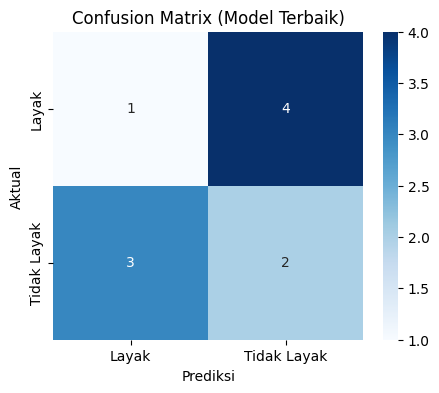

=== Laporan Klasifikasi (Model Terbaik) ===
              precision    recall  f1-score   support

       Layak       0.25      0.20      0.22         5
 Tidak Layak       0.33      0.40      0.36         5

    accuracy                           0.30        10
   macro avg       0.29      0.30      0.29        10
weighted avg       0.29      0.30      0.29        10

WandB run not active. Please re-run wandb.init() if you want to log results.


In [136]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi menggunakan model terbaik pada data uji
y_pred_best = rf_model_best.predict(X_test)

# Visualisasi Confusion Matrix untuk model terbaik
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix (Model Terbaik)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

print("=== Laporan Klasifikasi (Model Terbaik) ===")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

# Log ke W&B dan Akhiri Tracking (jika belum diakhiri)
# Inverse transform y_test and y_pred_best to original labels for wandb.plot.confusion_matrix
y_test_labels_best = encoder.inverse_transform(y_test)
y_pred_labels_best = encoder.inverse_transform(y_pred_best)

# Check if wandb run is still active before logging and finishing
if wandb.run is not None:
    wandb.log({
        "accuracy_best_model": accuracy_score(y_test, y_pred_best),
        "confusion_matrix_best_model": wandb.plot.confusion_matrix(probs=None, y_true=y_test.values, preds=y_pred_best, class_names=list(encoder.classes_))
    })
    wandb.finish()
else:
    print("WandB run not active. Please re-run wandb.init() if you want to log results.")

## 📊 Slide 7: Perbandingan Performa Model (Random Forest vs Gradient Boosting)

Untuk menentukan model terbaik, kita membandingkan akurasi akhir dari kedua algoritma yang telah diuji.

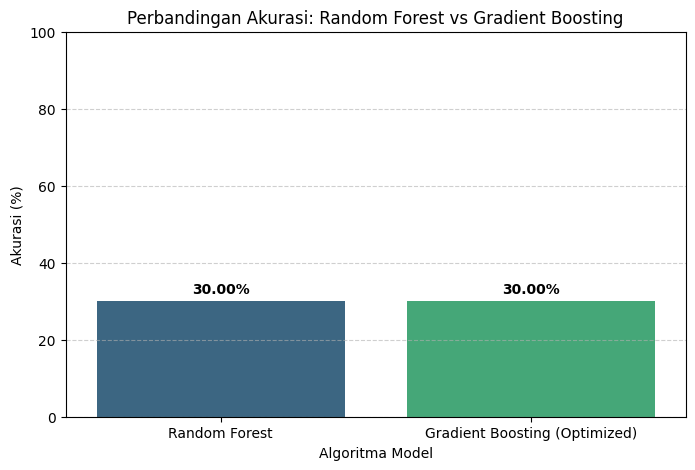

Akurasi Random Forest: 30.00%
Akurasi Gradient Boosting (Tuned): 30.00%


In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Hitung akurasi masing-masing model
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test))
gbc_accuracy = accuracy_score(y_test, gbc_model_best.predict(X_test))

# Data untuk plotting
models = ['Random Forest', 'Gradient Boosting (Optimized)']
accuracies = [rf_accuracy * 100, gbc_accuracy * 100]

# Visualisasi perbandingan
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis', hue=models, legend=False)

plt.ylim(0, 100)
plt.title('Perbandingan Akurasi: Random Forest vs Gradient Boosting')
plt.ylabel('Akurasi (%)')
plt.xlabel('Algoritma Model')

# Tambahkan label angka di atas bar
for i, val in enumerate(accuracies):
    # Menggunakan properti 'weight' yang benar untuk Matplotlib
    plt.text(i, val + 2, f'{val:.2f}%', horizontalalignment='center', weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Akurasi Random Forest: {rf_accuracy*100:.2f}%")
print(f"Akurasi Gradient Boosting (Tuned): {gbc_accuracy*100:.2f}%")